In [1]:
import pandas as pd
import pandana as pdna
from pandana.loaders import osm
import numpy as np
import warnings
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import osmnx as ox
import os
import timeit

ox.settings.use_cache = True

ox.settings.log_console = True

In [2]:
start = timeit.timeit() #timing
#osmnx
filepath = "./data/silkbronx_network.graphml"
bbox = 9.48446, 56.15291, 9.62522, 56.20804
if(os.path.exists(filepath)):
    G = ox.io.load_graphml(filepath)
else:
    G = ox.graph.graph_from_bbox(bbox, simplify = True)  
    #G = ox.graph.graph_from_place("Silkeborg Municipality, Denmark")
    ox.io.save_graphml(G, filepath)

G = ox.project_graph(G)

#pandana
filepath_pan = "./data/silkbronx_features.h5"

if(os.path.exists(filepath_pan)):
    n, e = ox.graph_to_gdfs(G)
    e = e.reset_index()
    network = pdna.Network.from_hdf5(filepath_pan)
else:
    n, e = ox.graph_to_gdfs(G)
    e = e.reset_index()
    network = pdna.Network(n.geometry.x, n.geometry.y, e["u"], e["v"], e[["length"]])
    
    network.save_hdf5(filepath_pan)

#places = ["silkeborg Municipality, Denmark",]

pois_a = ox.features_from_bbox(
    bbox,
    tags={"shop": ["supermarket", "convenience"]},
).to_crs(n.crs)

pois_b = ox.features_from_bbox(
    bbox,
    tags={"amenity": ["clinic", "pharmacy"]},
).to_crs(n.crs)
pois_c = ox.features_from_bbox(
    bbox,
    tags={"amenity": "school"},
).to_crs(n.crs)
pois_TURBO = ox.features_from_bbox(
    bbox,
    tags={"amenity": ["clinic", "pharmacy", "school"],"shop": ["supermarket", "convenience"]},
).to_crs(n.crs)

pois_a["geometry"] = pois_a.geometry.centroid


pois_b["geometry"] = pois_b.geometry.centroid


pois_c["geometry"] = pois_c.geometry.centroid

pois_TURBO["geometry"] = pois_TURBO.geometry.centroid
dist = 1000

network.set_pois(
    category="pois_a",
    maxdist=2000,
    maxitems=1000,
    x_col=pois_a.geometry.x,
    y_col=pois_a.geometry.y,
)
network.set_pois(
    category="pois_b",
    maxdist=2000,
    maxitems=1000,
    x_col=pois_b.geometry.x,
    y_col=pois_b.geometry.y,
)
network.set_pois(
    category="pois_c",
    maxdist=2000,
    maxitems=1000,
    x_col=pois_c.geometry.x,
    y_col=pois_c.geometry.y,
)
network.set_pois(
    category="pois_TURBO",
    maxdist=2000,
    maxitems=1000,
    x_col=pois_TURBO.geometry.x,
    y_col=pois_TURBO.geometry.y,
)
nearest_pois_a = network.nearest_pois(
    distance=2000,
    category="pois_a",
    num_pois=50,
)
n["pois_a"] = (nearest_pois_a <= dist).sum(axis=1)
nearest_pois_b = network.nearest_pois(
    distance=2000,
    category="pois_b",
    num_pois=50,
)
n["pois_b"] = (nearest_pois_b <= dist).sum(axis=1)

nearest_pois_c = network.nearest_pois(
    distance=2000,
    category="pois_c",
    num_pois=50,
)
n["pois_c"] = (nearest_pois_c <= dist).sum(axis=1)

nearest_pois_TURBO = network.nearest_pois(
    distance=2000,
    category="pois_TURBO",
    num_pois=50,
)
n["pois_TURBO"] = (nearest_pois_TURBO <= dist).sum(axis=1)


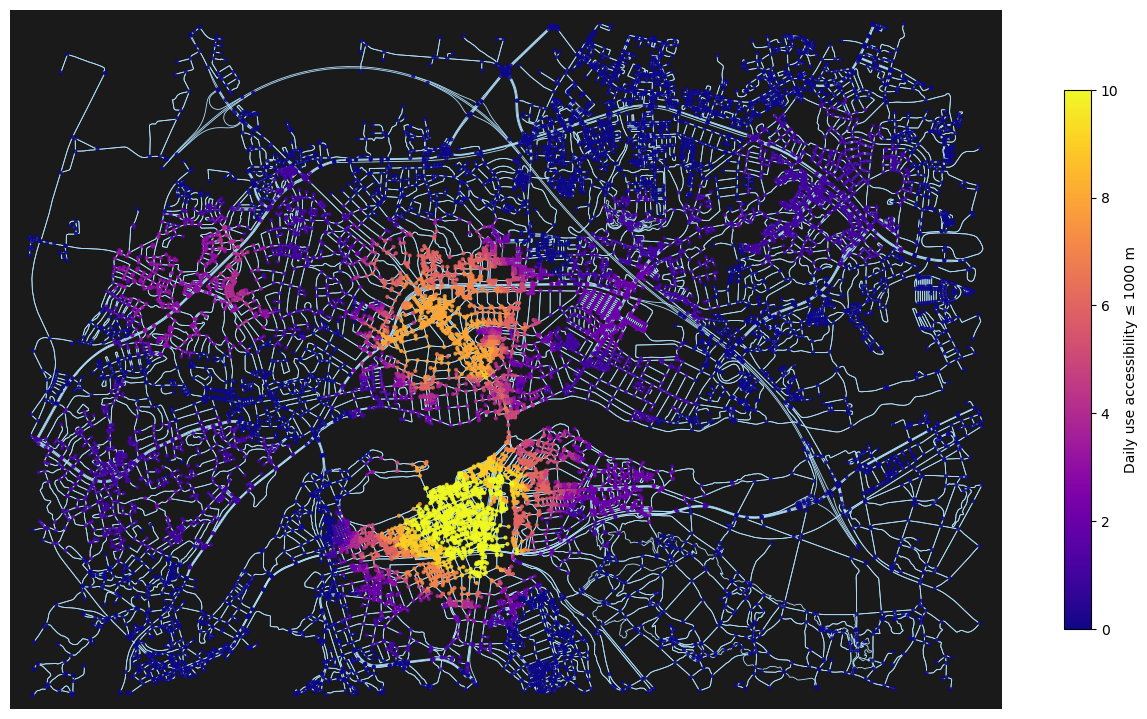

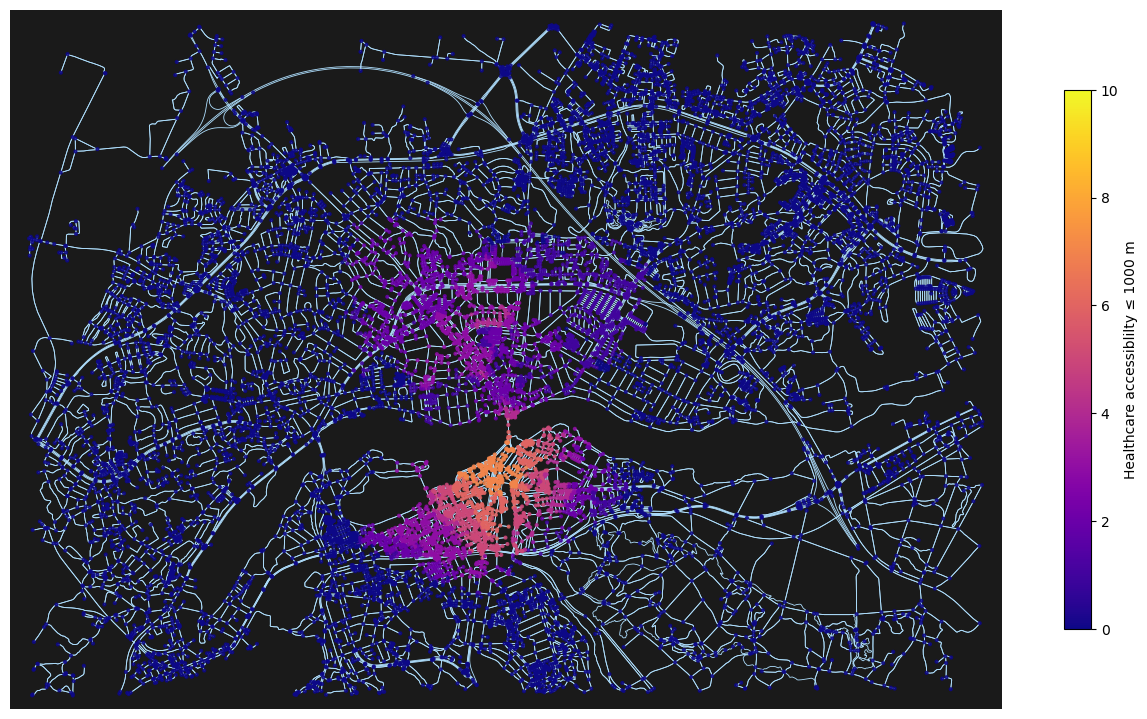

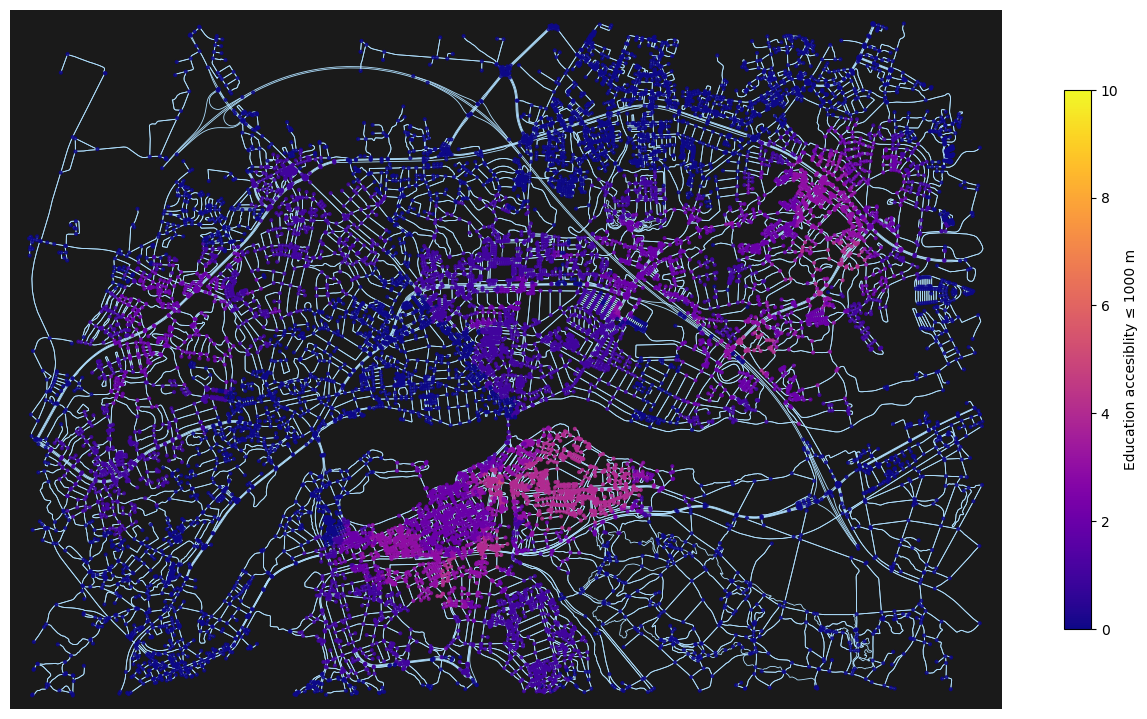

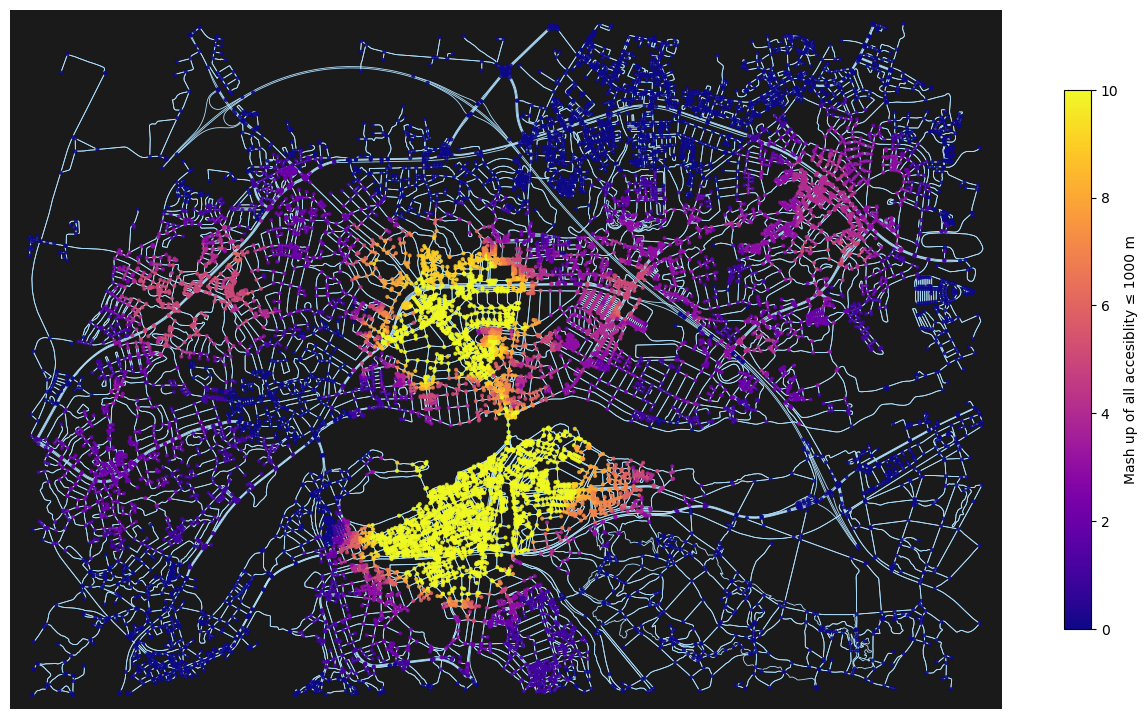

In [3]:
fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(16,14)
)

vmin = n["pois_a"].min()
vmax = n["pois_a"].max()

n.plot(
    ax=ax,
    column="pois_a",
    cmap="plasma",
    markersize=4,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Daily use accessibility ≤ {dist} m",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=10
)

plt.show()

fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(16,14)
)

vmin = n["pois_b"].min()
vmax = n["pois_b"].max()

n.plot(
    ax=ax,
    column="pois_b",
    cmap="plasma",
    markersize=4,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Healthcare accessiblilty ≤ {dist} m",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=10
)

plt.show()

fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(16,14)
)

vmin = n["pois_c"].min()
vmax = n["pois_c"].max()

n.plot(
    ax=ax,
    column="pois_c",
    cmap="plasma",
    markersize=4,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Education accesiblity ≤ {dist} m",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=10
)

plt.show()
# this is an attempt to calculate accessibility on all available tags
fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(16,14)
)

vmin = n["pois_TURBO"].min()
vmax = n["pois_TURBO"].max()

n.plot(
    ax=ax,
    column="pois_TURBO",
    cmap="plasma",
    markersize=4,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Mash up of all accesiblity ≤ {dist} m",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=10
)

plt.show()

Note:education and mashup appears to give the same result. pointing towards there being a flaw in the original mash-up technique.
(this was just a copy-paste error in generating the mash-up graph!, keeping in the original comment for now)

Note that the mash-up graph reaches the max of. and the graphs could be adjusted to 10 for a more accurate reading. though
the other graphs are a little too faint for my liking at 10 (did it anyway)


Below we then build our graph in different way. Such that each category only provides one poi(nt) so what we are looking at is the overlap of poi types

This give us a heatmap of areas where accessibility for our defined categories is displayed in a relativly sane way.

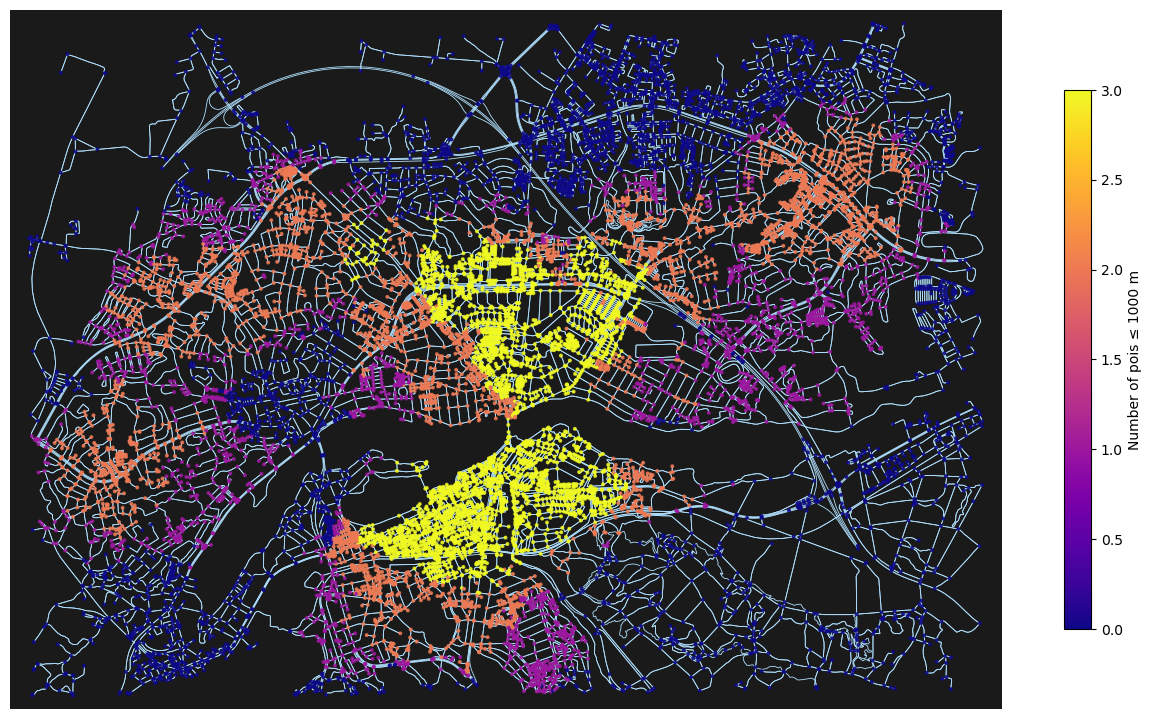

In [8]:
#assemble the network fot the graph. Only look for nearest 1 poi (cred 2 jonas for the tech)
nearest_pois = network.nearest_pois(
    distance=2000,
    category="pois_a",
    num_pois=1,
)
n["pois"] = (nearest_pois <= dist).sum(axis=1)


nearest_pois = network.nearest_pois(
    distance=2000,
    category="pois_b",
    num_pois=1,
)
n["pois"] = n["pois"] + (nearest_pois <= dist).sum(axis=1)

nearest_pois = network.nearest_pois(
    distance=2000,
    category="pois_c",
    num_pois=1,
)
n["pois"] = n["pois"] + (nearest_pois <= dist).sum(axis=1)

# Now we plot the graph as usual. As we have 3 types, the graph max is 3. set it to 4 tho, because i felt like it.
fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(16,14)
)

vmin = n["pois"].min()
vmax = n["pois"].max()

n.plot(
    ax=ax,
    column="pois",
    cmap="plasma",


    markersize=3.5,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Number of pois ≤ {dist} m",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=vmax
)

plt.show()

In [13]:

tags = {"amenity": ["school", "pharmacy","school"], "shop": ["convenience", "supermarket"]}
places = "silkeborg Municipality, Denmark"
#init tags
pois_arr = []
def tags_init(tags, places, pois_arr):
    counter = 0
    for x, y in tags.items():
        print(x , y)
        for itemz in y:
            pois_arr.append (ox.features_from_place(
                places,
                tags={x : itemz}
            ).to_crs(n.crs))
            pois_arr[counter]["geometry"] = pois_arr[counter].geometry.centroid
            counter += 1
tags_init(tags,places,pois_arr)

amenity ['school', 'pharmacy', 'school']
shop ['convenience', 'supermarket']


This is a more streamlined version of all the above cells.
Basically, you feed it a dictionary of tags, and a place. then i will pull the features from that place using the tag list.
the print just tells you what catagories and tags are pulled. (mostly for debugging)

In [16]:
distance = 2000
dist = 1000
maxitems = 1000
n["pois"] = 0
tagsc = []

for cat, tags_list in tags.items():
        for items in tags_list:
            tagsc.append(items)
print(tagsc)    
counta = 0
for items in pois_arr:
    network.set_pois(
                category= tagsc[counta],
                maxdist=distance,
                maxitems=maxitems,
                x_col=items.geometry.x,
                y_col=items.geometry.y,
                )
    nearest_pois = network.nearest_pois(
                distance=distance,
                category=tagsc[counta],
                num_pois=1,
                )
    counta += 1
    n["pois"] = n["pois"] + (nearest_pois <= dist).sum(axis=1)



['school', 'pharmacy', 'school', 'convenience', 'supermarket']


This cell unpacks all the tags, then uses them to preform point of interest search per tag.
This is then mashed up in a "atleast 1 " poi layer graph with all tags.


Note: this is slightly diffiernt than the graph generated with the layering method a few cells above. As that method lumps some tags together (clinic and pharmacy, supermarket and convenience)

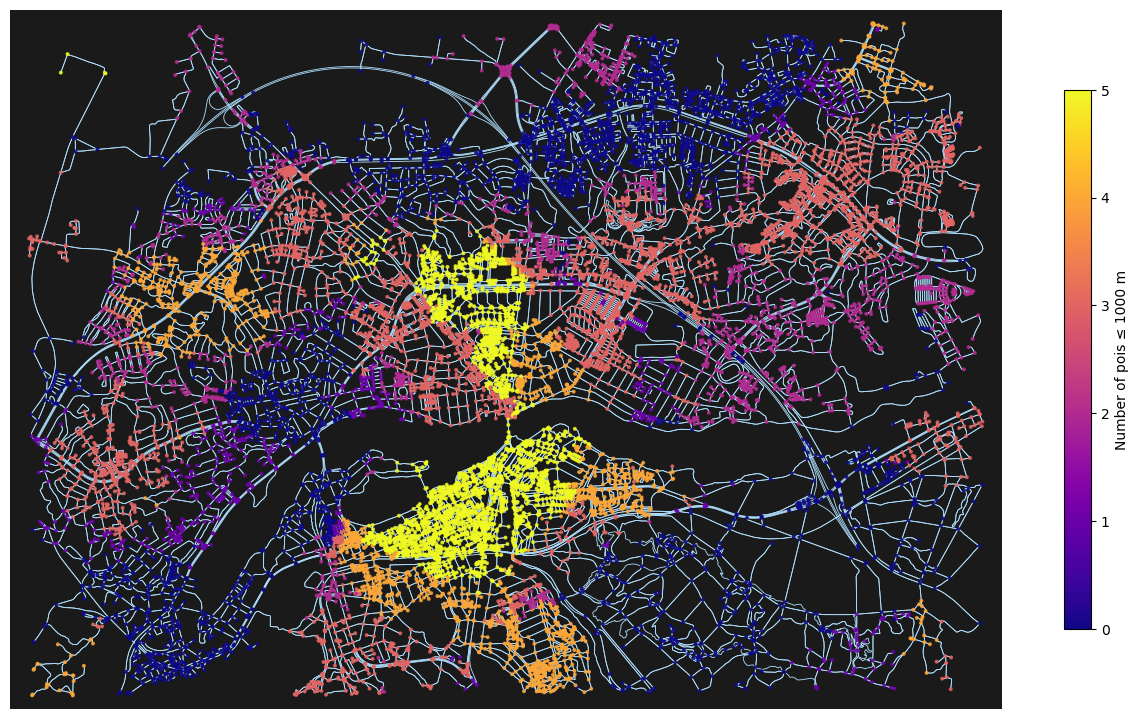

In [18]:
fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(16,14)
)

vmin = n["pois"].min()
vmax = n["pois"].max()

n.plot(
    ax=ax,
    column="pois",
    cmap="plasma",
    markersize=3.5,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Number of pois ≤ {dist} m",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=vmax
)

plt.show()

While it has already been mentioned, this is a 5 layer graph(at the time of writing), as every tag is a layer. whereas the previous mashup
simply layered pois_a, pois_b and pois_c. with each as a layer.